<a href="https://colab.research.google.com/github/NishigandhaChoudhury/Neural-Network-and-Deep-Learning-Lab-Experiments/blob/main/NNDLLAB12(10).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28, 1)


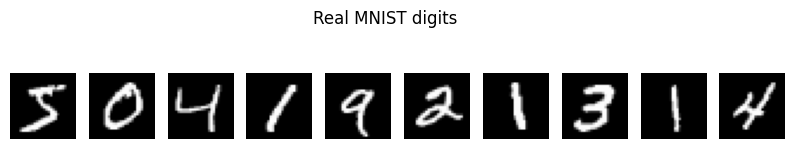

In [ ]:
# Load MNIST (auto-downloads ~11MB)
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

# Normalize to [-1, 1]  ← important for GAN stability
x_train = (x_train.astype("float32") - 127.5) / 127.5

# Add channel dimension: (60000, 28, 28) → (60000, 28, 28, 1)
x_train = x_train.reshape(-1, 28, 28, 1)

print("Training data shape:", x_train.shape)

# Preview real digits
plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(x_train[i].reshape(28,28), cmap='gray')
    plt.axis('off')
plt.suptitle("Real MNIST digits"); plt.show()

In [ ]:
def build_generator():
    model = models.Sequential([
        # Input: 100-dim noise vector
        layers.Dense(7 * 7 * 128, input_shape=(100,)),
        layers.Reshape((7, 7, 128)),

        # Upsample 7×7 → 14×14
        layers.Conv2DTranspose(64, (4,4), strides=2,
                               padding='same', activation='relu'),
        layers.BatchNormalization(),

        # Upsample 14×14 → 28×28
        layers.Conv2DTranspose(1, (4,4), strides=2,
                               padding='same', activation='tanh')
        # tanh output matches our [-1,1] normalization
    ])
    return model

generator = build_generator()
generator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6272)           │       633,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │       131,136 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 1)      │         1,025 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 765,889 (2.92 MB)

 Trainable params: 765,761 (2.92 MB)

 Non-trainable params: 128 (512.00 B)

In [ ]:
def build_discriminator():
    model = models.Sequential([
        # Input: 28×28×1 image
        layers.Conv2D(64, (4,4), strides=2, padding='same',
                      input_shape=(28,28,1)),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),

        layers.Conv2D(128, (4,4), strides=2, padding='same'),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(1, activation='sigmoid')  # Real=1, Fake=0
    ])
    return model

discriminator = build_discriminator()
discriminator.compile(optimizer=tf.keras.optimizers.Adam(0.0002),
                      loss='binary_crossentropy',
                      metrics=['accuracy'])
discriminator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,561 (541.25 KB)

 Trainable params: 138,561 (541.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Freeze discriminator when training the GAN
discriminator.trainable = False

# GAN: noise → generator → discriminator → real/fake label
gan_input  = tf.keras.Input(shape=(100,))
fake_img   = generator(gan_input)
gan_output = discriminator(fake_img)

gan = tf.keras.Model(gan_input, gan_output)
gan.compile(optimizer=tf.keras.optimizers.Adam(0.0002),
            loss='binary_crossentropy')

print("GAN model ready!")

GAN model ready!


In [ ]:
def show_generated(epoch, generator, n=10):
    noise = np.random.normal(0, 1, (n, 100))
    imgs  = generator.predict(noise, verbose=0)
    imgs  = (imgs + 1) / 2.0   # rescale [-1,1] → [0,1]

    plt.figure(figsize=(12, 2))
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(imgs[i].reshape(28,28), cmap='gray')
        plt.axis('off')
    plt.suptitle(f"Generated digits — Epoch {epoch}")
    plt.show()

Epoch 5/10 | D Loss: 0.6205 | G Loss: 1.0258


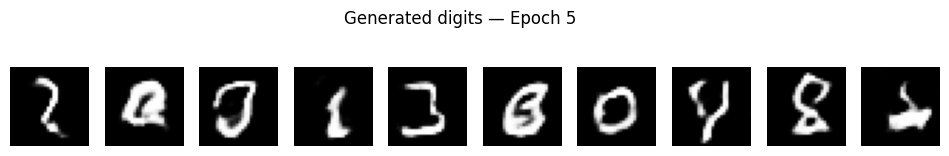

Epoch 10/10 | D Loss: 0.6253 | G Loss: 1.0159


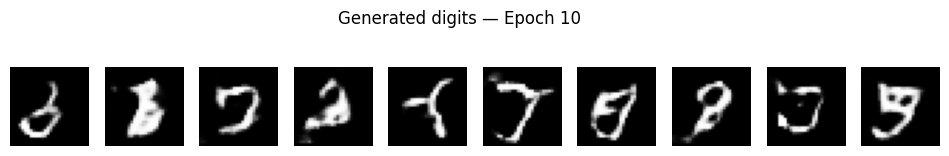

In [ ]:
EPOCHS     = 10       # increase to 200 for better quality
BATCH_SIZE = 128
NOISE_DIM  = 100

# Store losses for plotting
d_losses, g_losses = [], []

dataset = tf.data.Dataset.from_tensor_slices(x_train)\
            .shuffle(60000).batch(BATCH_SIZE)

for epoch in range(EPOCHS):
    d_loss_epoch, g_loss_epoch = [], []

    for real_imgs in dataset:
        batch = real_imgs.shape[0]

        # ── Step 1: Train Discriminator ──
        noise     = np.random.normal(0, 1, (batch, NOISE_DIM))
        fake_imgs = generator.predict(noise, verbose=0)

        # Labels: real=1, fake=0  (with label smoothing for stability)
        real_labels = np.ones((batch, 1)) * 0.9
        fake_labels = np.zeros((batch, 1))

        discriminator.trainable = True
        d_loss_real = discriminator.train_on_batch(real_imgs, real_labels)
        d_loss_fake = discriminator.train_on_batch(fake_imgs, fake_labels)
        d_loss = 0.5 * (d_loss_real[0] + d_loss_fake[0])

        # ── Step 2: Train Generator ──
        noise      = np.random.normal(0, 1, (batch, NOISE_DIM))
        valid_labels = np.ones((batch, 1))   # generator WANTS discriminator to say "real"

        discriminator.trainable = False
        g_loss = gan.train_on_batch(noise, valid_labels)

        d_loss_epoch.append(d_loss)
        g_loss_epoch.append(g_loss)

    # Average losses per epoch
    d_losses.append(np.mean(d_loss_epoch))
    g_losses.append(np.mean(g_loss_epoch))

    # Print progress every 5 epochs
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | "
              f"D Loss: {d_losses[-1]:.4f} | "
              f"G Loss: {g_losses[-1]:.4f}")
        show_generated(epoch + 1, generator)

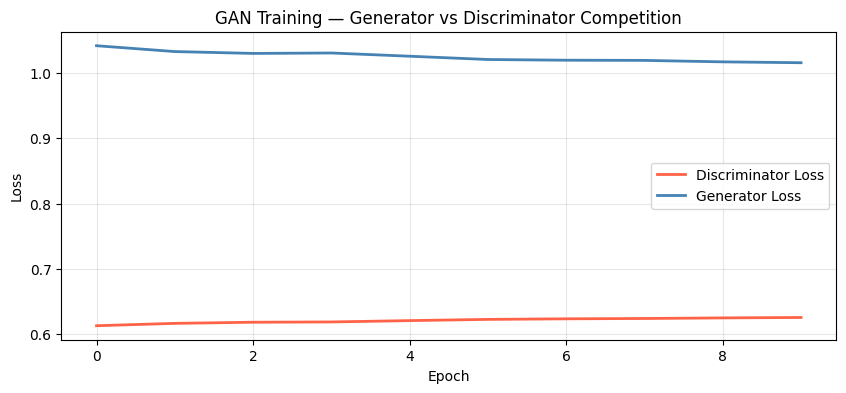

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(d_losses, label='Discriminator Loss', color='tomato',   linewidth=2)
plt.plot(g_losses, label='Generator Loss',     color='steelblue',linewidth=2)
plt.title('GAN Training — Generator vs Discriminator Competition')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

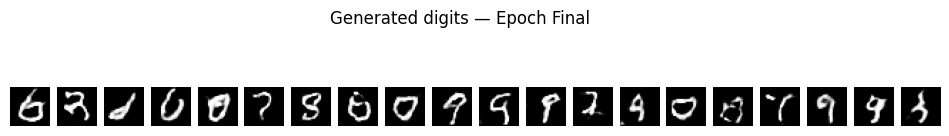

In [ ]:
show_generated("Final", generator, n=20)

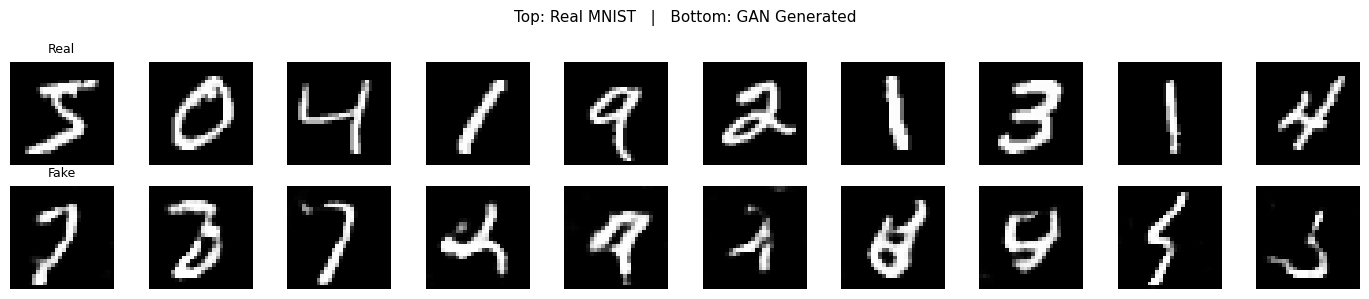

In [ ]:
noise     = np.random.normal(0, 1, (10, 100))
fake_imgs = generator.predict(noise, verbose=0)
fake_imgs = (fake_imgs + 1) / 2.0

fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for i in range(10):
    # Real
    axes[0, i].imshow(x_train[i].reshape(28,28), cmap='gray')
    axes[0, i].axis('off')
    if i == 0: axes[0, i].set_title("Real", fontsize=9)

    # Fake
    axes[1, i].imshow(fake_imgs[i].reshape(28,28), cmap='gray')
    axes[1, i].axis('off')
    if i == 0: axes[1, i].set_title("Fake", fontsize=9)

plt.suptitle("Top: Real MNIST   |   Bottom: GAN Generated", fontsize=11)
plt.tight_layout(); plt.show()